# **New York City Yellow Taxi Data**

## Objective
Exploratory Data Analysis (EDA) on 2023 NYC Yellow Taxi trip records to uncover operational, pricing and customer-experience insights.

## Problem Statement
As an analyst at an upcoming taxi operation in NYC, this notebook analyses the 2023 taxi trip data to uncover patterns that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

## **1** Data Preparation

### Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
print(os.getcwd())
print(os.listdir('.'))
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

c:\Users\gaura\OneDrive\Documents\Data _Setes\Starter-Notebook-EDA-NYC-Taxi\Solve
['nyc_taxi_2023_clean.parquet', 'nyc_taxi_2023_cleaned_sample.parquet', 'nyc_taxi_2023_sampled.parquet', 'NYC_Taxi_EDA_Solved.ipynb', 'yellow_tripdata_2023-01.parquet', 'yellow_tripdata_2023-02.parquet', 'yellow_tripdata_2023-03.parquet', 'yellow_tripdata_2023-04.parquet', 'yellow_tripdata_2023-05.parquet', 'yellow_tripdata_2023-06.parquet', 'yellow_tripdata_2023-07.parquet', 'yellow_tripdata_2023-08.parquet', 'yellow_tripdata_2023-09.parquet', 'yellow_tripdata_2023-10.parquet', 'yellow_tripdata_2023-11.parquet', 'yellow_tripdata_2023-12.parquet']


In [3]:
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.4.1
pandas version: 3.0.1
matplotlib version: 3.11.0
seaborn version: 0.13.2


### **1.1** Loading the dataset
Each month of 2023 is stored in its own parquet file (12 files). i first inspect one file to understand its size.

In [4]:
sample_file = sorted(glob.glob('yellow_tripdata_2023-*.parquet'))[0]
df_check = pd.read_parquet(sample_file)
df_check.info()
print("Rows in a single month:", len(df_check))

<class 'pandas.DataFrame'>
RangeIndex: 3066766 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            float64   

Each month has 2.8–3.5 million rows; twelve months combined would be well over 35 million rows. Loading and manipulating that in memory for an exploratory analysis is not practical on a typical laptop, so i **sample** a representative fraction from each month instead of loading everything.

**Sampling strategy:** demand for taxis varies strongly by hour of day (rush hour vs. 3 AM) and this pattern differs by weekday/weekend and by season. i sampled *uniformly at random* across a whole month, purely by chance i could still end up representing all hours proportionally — but to be safe and explicit, i sample independently **within every (date, hour) bucket**, so the hourly/daily demand shape of the original data is preserved exactly in the sample, and no single hour or day dominates or is under-represented due to sampling noise.

#### Sampling the Data
For every date in a month, i split records by pickup hour and draw a fixed 0.75% random sample from each (date, hour) group, then concatenate. Averaged over 12 months this yields close to the recommended ~250,000–300,000 rows.

---

**1.1.1** Sample and combine the twelve monthly files.

**Note:** Sampling is performed per (date, hour) bucket rather than only per hour, because sampling only by hour-of-day across the whole month would flatten day-to-day variation (e.g. a Monday vs a public holiday) into a single hour-level average; sampling by (date, hour) keeps each individual day's hourly shape intact before we combine everything.

In [5]:
SAMPLE_FRAC = 0.0075     # ~0.75% per (date, hour) bucket -> ~250k-300k rows across 12 months
RANDOM_STATE = 42

files = sorted(glob.glob('yellow_tripdata_2023-*.parquet'))
files

['yellow_tripdata_2023-01.parquet',
 'yellow_tripdata_2023-02.parquet',
 'yellow_tripdata_2023-03.parquet',
 'yellow_tripdata_2023-04.parquet',
 'yellow_tripdata_2023-05.parquet',
 'yellow_tripdata_2023-06.parquet',
 'yellow_tripdata_2023-07.parquet',
 'yellow_tripdata_2023-08.parquet',
 'yellow_tripdata_2023-09.parquet',
 'yellow_tripdata_2023-10.parquet',
 'yellow_tripdata_2023-11.parquet',
 'yellow_tripdata_2023-12.parquet']

In [ ]:
# It is recommended to not load all 12 files at once to avoid memory overload.
# i process one month at a time: read -> sample per (date, hour) -> release the full month from memory.

all_samples = []

for f in files:
    month_df = pd.read_parquet(f)
    month_df = month_df[month_df['tpep_pickup_datetime'].dt.year == 2023]  # guard against stray rows
    month_df['pickup_date'] = month_df['tpep_pickup_datetime'].dt.date
    month_df['pickup_hr_tmp'] = month_df['tpep_pickup_datetime'].dt.hour

    sampled = (
        month_df.groupby(['pickup_date', 'pickup_hr_tmp'], group_keys=False)
                .apply(lambda x: x.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE) if len(x) else x)
    )
    sampled = sampled.drop(columns=[c for c in ['pickup_date', 'pickup_hr_tmp'] if c in sampled.columns])
    print(f"{os.path.basename(f):45s} total={len(month_df):>9,}   sampled={len(sampled):>7,}")

    all_samples.append(sampled)
    del month_df  # free memory before moving to next month

df = pd.concat(all_samples, ignore_index=True)
print("\nTotal combined sampled rows:", f"{len(df):,}")

yellow_tripdata_2023-01.parquet               total=3,066,728   sampled= 23,002
yellow_tripdata_2023-02.parquet               total=2,913,950   sampled= 21,848
yellow_tripdata_2023-03.parquet               total=3,403,755   sampled= 25,524
yellow_tripdata_2023-04.parquet               total=3,288,242   sampled= 24,660
yellow_tripdata_2023-05.parquet               total=3,513,644   sampled= 26,341
yellow_tripdata_2023-06.parquet               total=3,307,228   sampled= 24,795
yellow_tripdata_2023-07.parquet               total=2,907,104   sampled= 21,801
yellow_tripdata_2023-08.parquet               total=2,824,202   sampled= 21,186
yellow_tripdata_2023-09.parquet               total=2,846,716   sampled= 21,350
yellow_tripdata_2023-10.parquet               total=3,522,281   sampled= 26,417
yellow_tripdata_2023-11.parquet               total=3,339,714   sampled= 25,050
yellow_tripdata_2023-12.parquet               total=3,376,558   sampled= 25,322

Total combined sampled rows: 287,296


After combining the twelve months into one DataFrame, we persist it as a single parquet file so the rest of the notebook can simply reload it directly, without repeating the expensive sampling step.

In [7]:
df.to_parquet('nyc_taxi_2023_sampled.parquet', index=False)
print("Saved combined sample:", df.shape)

Saved combined sample: (287296, 20)


## **2** Data Cleaning

Now i have load the sampled data directly.

In [8]:
df = pd.read_parquet('nyc_taxi_2023_sampled.parquet')
df.shape

(287296, 20)

In [9]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
0,2,2023-01-01 00:10:30,2023-01-01 00:11:49,1.0,0.49,1.0,N,239,238,1,4.4,1.0,0.5,1.88,0.00,1.0,11.28,2.5,0.0,NaN
1,2,2023-01-01 00:49:02,2023-01-01 00:55:15,1.0,0.75,1.0,N,45,148,2,7.9,1.0,0.5,0.00,0.00,1.0,12.90,2.5,0.0,NaN
2,1,2023-01-01 00:47:17,2023-01-01 01:07:01,2.0,2.90,1.0,N,142,170,1,19.1,3.5,0.5,4.80,0.00,1.0,28.90,2.5,0.0,NaN
3,2,2023-01-01 00:06:02,2023-01-01 00:31:38,1.0,2.50,1.0,N,43,161,1,24.0,1.0,0.5,7.25,0.00,1.0,36.25,2.5,0.0,NaN
4,2,2023-01-01 00:02:19,2023-01-01 00:30:49,1.0,20.37,2.0,N,132,140,1,70.0,0.0,0.5,12.00,6.55,1.0,92.55,2.5,0.0,NaN


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 287296 entries, 0 to 287295
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               287296 non-null  int64         
 1   tpep_pickup_datetime   287296 non-null  datetime64[us]
 2   tpep_dropoff_datetime  287296 non-null  datetime64[us]
 3   passenger_count        277830 non-null  float64       
 4   trip_distance          287296 non-null  float64       
 5   RatecodeID             277830 non-null  float64       
 6   store_and_fwd_flag     277830 non-null  str           
 7   PULocationID           287296 non-null  int64         
 8   DOLocationID           287296 non-null  int64         
 9   payment_type           287296 non-null  int64         
 10  fare_amount            287296 non-null  float64       
 11  extra                  287296 non-null  float64       
 12  mta_tax                287296 non-null  float64       


### **2.1** Fixing Columns

**2.1.1** Fix the index and drop unnecessary columns.

In [11]:
df = df.reset_index(drop=True)

# store_and_fwd_flag only indicates a communication/technical detail about how the
# record reached the vendor's server -- it carries no operational, pricing or
# customer-experience signal for this analysis, so we drop it.
df = df.drop(columns=['store_and_fwd_flag'])
df.shape

(287296, 19)

**2.1.2** There are two airport fee columns (`airport_fee` and `Airport_fee`). This happens because the January file uses lowercase `airport_fee` while all other months use `Airport_fee`; when combined, pandas treats them as two separate columns. Let's combine them into one.

In [12]:
print(df[['airport_fee', 'Airport_fee']].isna().sum())

df['airport_fee'] = df['airport_fee'].fillna(0) + df['Airport_fee'].fillna(0)
df = df.drop(columns=['Airport_fee'])
df['airport_fee'].describe()

airport_fee    264809
Airport_fee     31953
dtype: int64


count    287296.000000
mean          0.134039
std           0.459233
min          -1.750000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.750000
Name: airport_fee, dtype: float64

**2.1.3** Fix columns with negative (monetary) values.

In [13]:
print("Negative fare_amount rows:", (df['fare_amount'] < 0).sum())
df[df['fare_amount'] < 0].head()

Negative fare_amount rows: 2850


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
90,2,2023-01-01 02:29:07,2023-01-01 02:29:24,1.0,0.00,3.0,234,234,4,-23.0,-1.0,0.0,0.0,0.0,-1.0,-25.0,0.0,0.0
182,2,2023-01-01 06:36:37,2023-01-01 06:44:17,1.0,1.84,1.0,162,100,4,-10.7,0.0,-0.5,0.0,0.0,-1.0,-14.7,-2.5,0.0
218,2,2023-01-01 10:15:22,2023-01-01 10:15:30,1.0,0.00,1.0,75,75,1,-3.0,0.0,-0.5,0.0,0.0,-1.0,-4.5,0.0,0.0
291,2,2023-01-01 13:15:52,2023-01-01 13:28:52,1.0,2.47,1.0,246,125,4,-14.9,0.0,-0.5,0.0,0.0,-1.0,-18.9,-2.5,0.0
612,2,2023-01-02 07:11:35,2023-01-02 07:11:43,1.0,0.00,1.0,100,100,3,-3.0,0.0,-0.5,0.0,0.0,-1.0,-7.0,-2.5,0.0


Did you notice something different in the `RatecodeID` column for the above records?

In [14]:
df[df['fare_amount'] < 0]['RatecodeID'].value_counts(dropna=False)

RatecodeID
1.0    2513
2.0     206
NaN      44
5.0      43
3.0      29
4.0      15
Name: count, dtype: int64

The negative-fare records don't share one distinctive RatecodeID; they are spread across the usual rate codes. They also all belong to `VendorID == 2` and are concentrated in `payment_type` 3 (no charge) and 4 (dispute) -- consistent with reversal/refund bookkeeping entries for the *same* trip rather than genuinely different transactions, so the safest fix is to take the absolute value rather than dropping the trips outright.

In [15]:
money_cols = ['fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount',
              'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']

print("Columns with negative values and their counts:")
for c in money_cols:
    n = (df[c] < 0).sum()
    if n:
        print(f"  {c}: {n}")

Columns with negative values and their counts:
  fare_amount: 2850
  extra: 1455
  mta_tax: 2749
  tip_amount: 14
  tolls_amount: 183
  improvement_surcharge: 2821
  total_amount: 2824
  congestion_surcharge: 2266
  airport_fee: 381


In [16]:
for c in money_cols:
    df[c] = df[c].abs()

print("Remaining negative cells across monetary columns:", (df[money_cols] < 0).sum().sum())

Remaining negative cells across monetary columns: 0


### **2.2** Handling Missing Values

**2.2.1** Find the proportion of missing values in each column.

In [17]:
(df.isna().mean() * 100).round(2).sort_values(ascending=False)

RatecodeID               3.29
passenger_count          3.29
congestion_surcharge     3.29
VendorID                 0.00
tpep_pickup_datetime     0.00
tpep_dropoff_datetime    0.00
PULocationID             0.00
DOLocationID             0.00
payment_type             0.00
trip_distance            0.00
fare_amount              0.00
extra                    0.00
tip_amount               0.00
mta_tax                  0.00
tolls_amount             0.00
improvement_surcharge    0.00
total_amount             0.00
airport_fee              0.00
dtype: float64

**2.2.2** Handling missing values in `passenger_count`.

In [18]:
df[df['passenger_count'].isna()].head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
5,2,2023-01-01 00:45:00,2023-01-01 01:21:00,NaN,6.00,NaN,234,225,0,38.77,0.0,0.5,0.00,0.0,1.0,42.77,NaN,0.0
6,2,2023-01-01 00:56:00,2023-01-01 01:08:45,NaN,2.89,NaN,181,17,0,17.17,0.0,0.5,3.73,0.0,1.0,22.40,NaN,0.0
38,2,2023-01-01 00:45:00,2023-01-01 01:04:00,NaN,5.25,NaN,256,162,0,28.36,0.0,0.5,2.27,0.0,1.0,34.63,NaN,0.0
70,2,2023-01-01 01:45:11,2023-01-01 02:00:49,NaN,6.27,NaN,209,140,0,29.31,0.0,0.5,6.66,0.0,1.0,39.97,NaN,0.0
73,2,2023-01-01 01:39:32,2023-01-01 01:51:28,NaN,3.53,NaN,41,141,0,20.92,0.0,0.5,4.84,0.0,0.3,29.06,NaN,0.0


`passenger_count` is missing for the same rows where `RatecodeID` is also missing (likely one vendor's under-reported records). We also check for zero values, which are physically impossible for a completed trip.

In [19]:
print("Zero passenger_count rows:", (df['passenger_count'] == 0).sum())

mode_pc = df['passenger_count'].mode()[0]
print("Mode passenger_count:", mode_pc)

df['passenger_count'] = df['passenger_count'].fillna(mode_pc)
df.loc[df['passenger_count'] == 0, 'passenger_count'] = mode_pc
df['passenger_count'].isna().sum(), (df['passenger_count'] == 0).sum()

Zero passenger_count rows: 4341
Mode passenger_count: 1.0


(np.int64(0), np.int64(0))

**2.2.3** Handle missing values in `RatecodeID`.

In [20]:
df['RatecodeID'].value_counts(dropna=False)

RatecodeID
1.0     262090
2.0      11055
NaN       9466
5.0       1618
99.0      1560
3.0        946
4.0        559
6.0          2
Name: count, dtype: int64

Code `99` isn't defined in the data dictionary (valid codes are 1-6), so we treat it the same as missing. Since "Standard rate" (1) accounts for the overwhelming majority of trips, we impute both NaN and 99 with 1.

In [21]:
df['RatecodeID'] = df['RatecodeID'].fillna(1)
df.loc[df['RatecodeID'] == 99, 'RatecodeID'] = 1
df['RatecodeID'].value_counts(dropna=False)

RatecodeID
1.0    273116
2.0     11055
5.0      1618
3.0       946
4.0       559
6.0         2
Name: count, dtype: int64

**2.2.4** Impute NaN in `congestion_surcharge`.

In [22]:
df['congestion_surcharge'].value_counts(dropna=False).head()

congestion_surcharge
2.5    256126
0.0     21704
NaN      9466
Name: count, dtype: int64

In [23]:
# Missing congestion_surcharge most plausibly means no surcharge was recorded/applied
df['congestion_surcharge'] = df['congestion_surcharge'].fillna(0)
df['congestion_surcharge'].isna().sum()

np.int64(0)

Are there missing values in any other columns?

In [24]:
df.isna().sum()[df.isna().sum() > 0]

Series([], dtype: int64)

No further missing values remain after the fixes above.

### **2.3** Handling Outliers

Before fixing outliers, i have perform outlier analysis.

In [25]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
VendorID,287296.0,1.736408,1.0,1.0,2.0,2.0,6.0,0.444749
tpep_pickup_datetime,287296,2023-07-02 23:09:40.409957,2023-01-01 00:02:19,2023-04-02 18:23:02.250000,2023-06-27 19:01:04,2023-10-06 22:11:18.750000,2023-12-31 23:54:57,NaN
tpep_dropoff_datetime,287296,2023-07-02 23:27:09.371975,2023-01-01 00:11:49,2023-04-02 18:44:34,2023-06-27 19:11:19.500000,2023-10-06 22:29:15.500000,2024-01-01 00:07:43,NaN
passenger_count,287296.0,1.374032,1.0,1.0,1.0,1.0,8.0,0.86504
trip_distance,287296.0,4.287558,0.0,1.04,1.78,3.4,116439.71,257.224622
RatecodeID,287296.0,1.073464,1.0,1.0,1.0,1.0,6.0,0.392491
PULocationID,287296.0,165.034699,1.0,132.0,162.0,234.0,265.0,64.07934
DOLocationID,287296.0,163.925982,1.0,114.0,162.0,234.0,265.0,69.838191
payment_type,287296.0,1.187305,0.0,1.0,1.0,1.0,4.0,0.55648
fare_amount,287296.0,19.863859,0.0,9.3,13.5,21.9,715.6,18.546506


In [26]:
print("trip_distance > 250 miles:", (df['trip_distance'] > 250).sum())
print("trip_distance ~0 & fare_amount > 300:", ((df['trip_distance'] < 0.05) & (df['fare_amount'] > 300)).sum())
print("trip_distance==0 & fare_amount==0 but different zones:",
      ((df['trip_distance'] == 0) & (df['fare_amount'] == 0) & (df['PULocationID'] != df['DOLocationID'])).sum())
print("payment_type == 0 (undefined):", (df['payment_type'] == 0).sum())
print("passenger_count > 6:", (df['passenger_count'] > 6).sum())

trip_duration_min = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60
print("trip_duration <= 0 minutes:", (trip_duration_min <= 0).sum())
print("trip_duration > 5 hours:", (trip_duration_min > 300).sum())

trip_distance > 250 miles: 6
trip_distance ~0 & fare_amount > 300: 11
trip_distance==0 & fare_amount==0 but different zones: 14
payment_type == 0 (undefined): 9466
passenger_count > 6: 4
trip_duration <= 0 minutes: 120
trip_duration > 5 hours: 259


**2.3.1** Based on the above analysis, several outliers are clearly data-registration errors rather than genuine trips. We handle each case as follows:

* `trip_distance` almost 0 with `fare_amount` > \$300 -> not a real trip (meter/GPS error) -> **drop**
* `trip_distance` == 0 and `fare_amount` == 0 but pickup/dropoff zones differ (physically impossible) -> **drop**
* `trip_distance` > 250 miles -> clearly a GPS/meter error for a NYC taxi trip -> **drop**
* `payment_type` == 0 (undefined in the data dictionary) -> **drop**
* Trips with `trip_duration` <= 0 or > 5 hours -> clock/meter error -> **drop**

First, we remove trips with 7+ passengers, since there are very few such instances and a standard yellow cab cannot legally carry that many passengers.

In [27]:
print("Rows before:", len(df))
df = df[df['passenger_count'] <= 6]
print("Rows after removing passenger_count > 6:", len(df))

Rows before: 287296
Rows after removing passenger_count > 6: 287292


In [28]:
mask_a = (df['trip_distance'] < 0.05) & (df['fare_amount'] > 300)
mask_b = (df['trip_distance'] == 0) & (df['fare_amount'] == 0) & (df['PULocationID'] != df['DOLocationID'])
mask_c = df['trip_distance'] > 250
mask_d = df['payment_type'] == 0

drop_mask = mask_a | mask_b | mask_c | mask_d
print("Rows flagged as outliers:", drop_mask.sum())
df = df[~drop_mask].copy()
print("Rows after dropping fare/distance/payment-type outliers:", len(df))

Rows flagged as outliers: 9493
Rows after dropping fare/distance/payment-type outliers: 277799


In [29]:
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

before = len(df)
df = df[(df['trip_duration'] > 0) & (df['trip_duration'] < 300)]
print(f"Dropped {before - len(df)} rows with invalid trip_duration (<=0 or >5 hours)")
print("Final shape after outlier handling:", df.shape)

Dropped 350 rows with invalid trip_duration (<=0 or >5 hours)
Final shape after outlier handling: (277449, 19)


Standardise column dtypes for the categorical fields, and engineer time-based features used throughout the EDA.

In [30]:
df['VendorID'] = df['VendorID'].astype('category')
df['RatecodeID'] = df['RatecodeID'].astype(int).astype('category')
df['payment_type'] = df['payment_type'].astype('category')
df['passenger_count'] = df['passenger_count'].astype(int)

df['pickup_hour']  = df['tpep_pickup_datetime'].dt.hour
df['pickup_day']   = df['tpep_pickup_datetime'].dt.day_name()
df['pickup_dow']   = df['tpep_pickup_datetime'].dt.dayofweek   # 0 = Monday
df['is_weekend']   = df['pickup_dow'].isin([5, 6])
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month
df['quarter']      = df['tpep_pickup_datetime'].dt.quarter

df.to_parquet('nyc_taxi_2023_clean.parquet', index=False)
df.info()

<class 'pandas.DataFrame'>
Index: 277449 entries, 0 to 287295
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               277449 non-null  category      
 1   tpep_pickup_datetime   277449 non-null  datetime64[us]
 2   tpep_dropoff_datetime  277449 non-null  datetime64[us]
 3   passenger_count        277449 non-null  int64         
 4   trip_distance          277449 non-null  float64       
 5   RatecodeID             277449 non-null  category      
 6   PULocationID           277449 non-null  int64         
 7   DOLocationID           277449 non-null  int64         
 8   payment_type           277449 non-null  category      
 9   fare_amount            277449 non-null  float64       
 10  extra                  277449 non-null  float64       
 11  mta_tax                277449 non-null  float64       
 12  tip_amount             277449 non-null  float64       
 13  

## **3** Exploratory Data Analysis

In [31]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee',
 'trip_duration',
 'pickup_hour',
 'pickup_day',
 'pickup_dow',
 'is_weekend',
 'pickup_month',
 'quarter']

#### **3.1** General EDA: Finding Patterns and Trends

**3.1.1** Categorise the variables into Numerical or Categorical.

| Variable | Type |
|---|---|
| `VendorID` | Categorical (nominal code, 2 values) |
| `tpep_pickup_datetime` | Datetime (temporal) |
| `tpep_dropoff_datetime` | Datetime (temporal) |
| `passenger_count` | Numerical (discrete) |
| `trip_distance` | Numerical (continuous) |
| `RatecodeID` | Categorical (nominal code) |
| `PULocationID` | Categorical (nominal, zone identifier) |
| `DOLocationID` | Categorical (nominal, zone identifier) |
| `payment_type` | Categorical (nominal code) |
| `pickup_hour` | Numerical, but used as categorical/ordinal for grouping |
| `trip_duration` | Numerical (continuous) |

All the monetary parameters -- `fare_amount`, `extra`, `mta_tax`, `tip_amount`, `tolls_amount`, `improvement_surcharge`, `total_amount`, `congestion_surcharge`, `airport_fee` -- are **numerical (continuous)** variables.

##### Temporal Analysis

**3.1.2** Analyse the distribution of taxi pickups by hours, days of the week, and months.

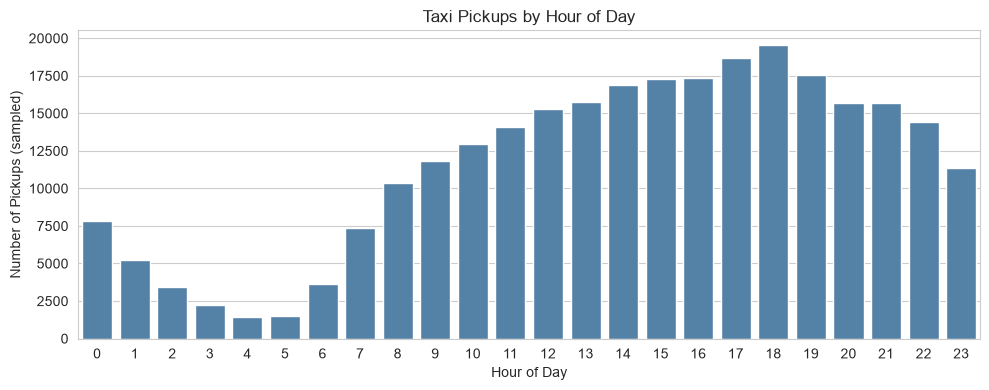

Busiest hour: 18 with 19541 sampled pickups


In [32]:
hourly = df.groupby('pickup_hour').size()

plt.figure(figsize=(10, 4))
sns.barplot(x=hourly.index, y=hourly.values, color='steelblue')
plt.title('Taxi Pickups by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Pickups (sampled)')
plt.tight_layout()
plt.show()

print("Busiest hour:", hourly.idxmax(), "with", hourly.max(), "sampled pickups")

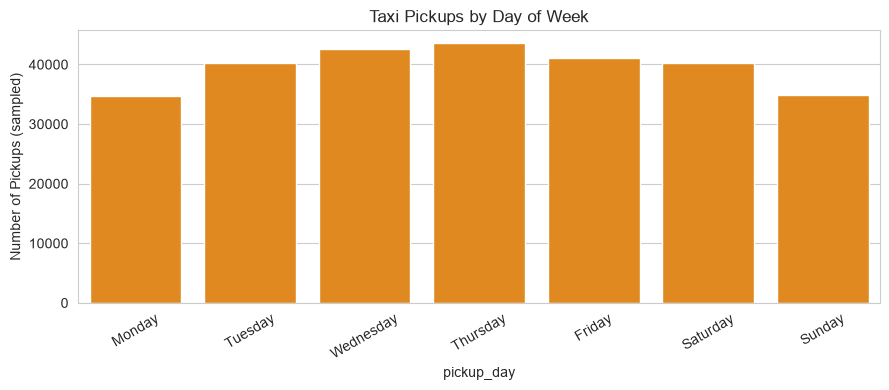

Busiest day: Thursday


In [33]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = df.groupby('pickup_day').size().reindex(day_order)

plt.figure(figsize=(9, 4))
sns.barplot(x=daily.index, y=daily.values, color='darkorange')
plt.title('Taxi Pickups by Day of Week')
plt.ylabel('Number of Pickups (sampled)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print("Busiest day:", daily.idxmax())

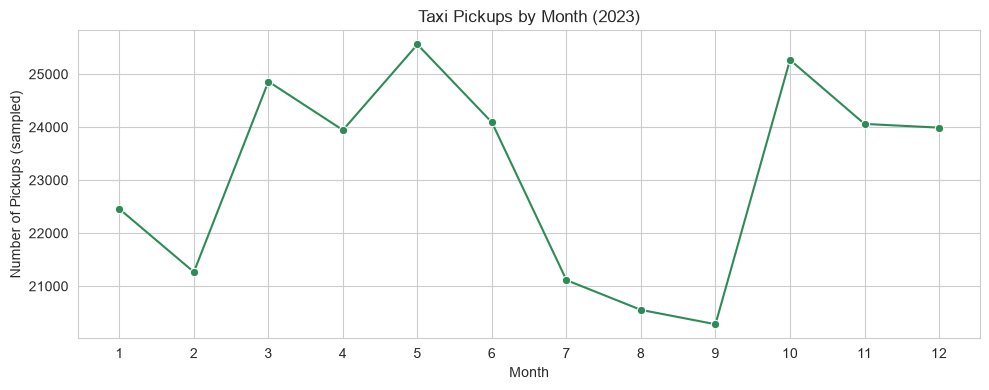

Busiest month: 5


In [34]:
monthly = df.groupby('pickup_month').size()

plt.figure(figsize=(10, 4))
sns.lineplot(x=monthly.index, y=monthly.values, marker='o', color='seagreen')
plt.title('Taxi Pickups by Month (2023)')
plt.xlabel('Month')
plt.ylabel('Number of Pickups (sampled)')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

print("Busiest month:", monthly.idxmax())

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and `trip_distance`. Do these contain zero/negative values?

In [35]:
for col in ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']:
    print(f"{col:15s} zeros: {(df[col]==0).sum():>7,}   negatives: {(df[col]<0).sum():>5,}")

fare_amount     zeros:      86   negatives:     0
tip_amount      zeros:  64,132   negatives:     0
total_amount    zeros:      39   negatives:     0
trip_distance   zeros:   3,661   negatives:     0


Since negative values were already fixed during cleaning, only zeros remain. Zero `trip_distance`/`fare_amount` can be legitimate (e.g. a cancelled trip logged at the meter, or pickup==dropoff zone), so it's worth analysing revenue/distance relationships on a filtered copy rather than deleting these rows from the main dataset.

**3.1.3** Filter out the zero values from the above columns for revenue/distance-relationship analysis. (Note: 0 distance can be legitimate when pickup and dropoff fall in the same zone, so we keep those rows in the main `df` and only exclude zeros in a working copy used for these specific analyses.)

In [36]:
df_nz = df[(df['fare_amount'] > 0) & (df['trip_distance'] > 0) & (df['total_amount'] > 0)].copy()
print("Original:", df.shape, " Non-zero subset:", df_nz.shape)

Original: (277449, 25)  Non-zero subset: (273745, 25)


**3.1.4** Analyse the monthly revenue (`total_amount`) trend.

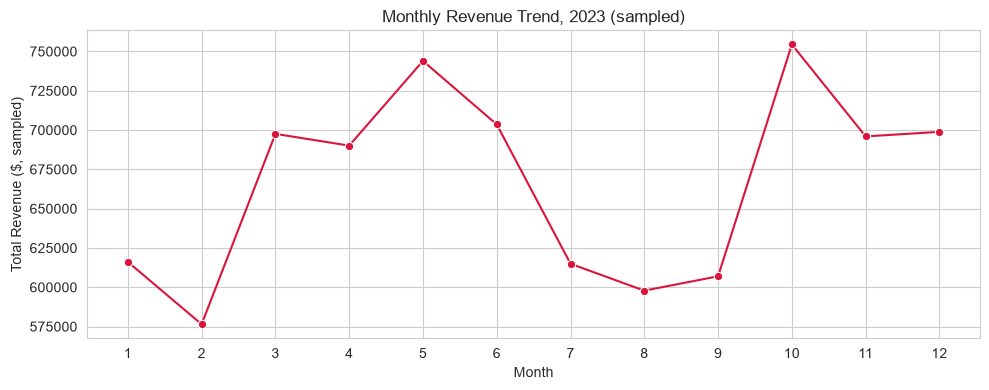

Highest-revenue month: 10  Lowest-revenue month: 2


In [37]:
monthly_rev = df.groupby('pickup_month')['total_amount'].sum()

plt.figure(figsize=(10, 4))
sns.lineplot(x=monthly_rev.index, y=monthly_rev.values, marker='o', color='crimson')
plt.title('Monthly Revenue Trend, 2023 (sampled)')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($, sampled)')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

print("Highest-revenue month:", monthly_rev.idxmax(), " Lowest-revenue month:", monthly_rev.idxmin())

**3.1.5** Show the proportion of each quarter of the year in the revenue.

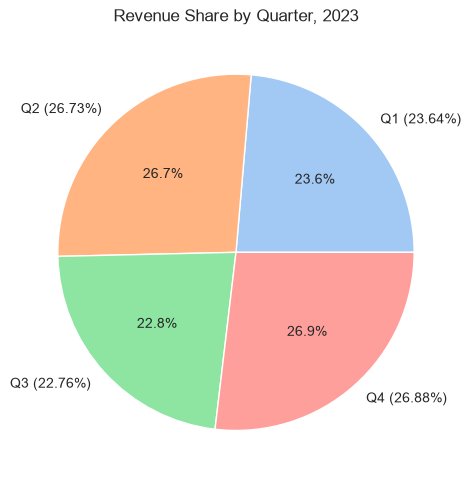

quarter
1    23.64
2    26.73
3    22.76
4    26.88
Name: total_amount, dtype: float64

In [38]:
quarter_rev = df.groupby('quarter')['total_amount'].sum()
quarter_share = (quarter_rev / quarter_rev.sum() * 100).round(2)

plt.figure(figsize=(5, 5))
plt.pie(quarter_share.values, labels=[f"Q{q} ({v}%)" for q, v in quarter_share.items()],
        autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Revenue Share by Quarter, 2023')
plt.tight_layout()
plt.show()

quarter_share

**3.1.6** Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two (leaving out trips with `trip_distance` = 0).

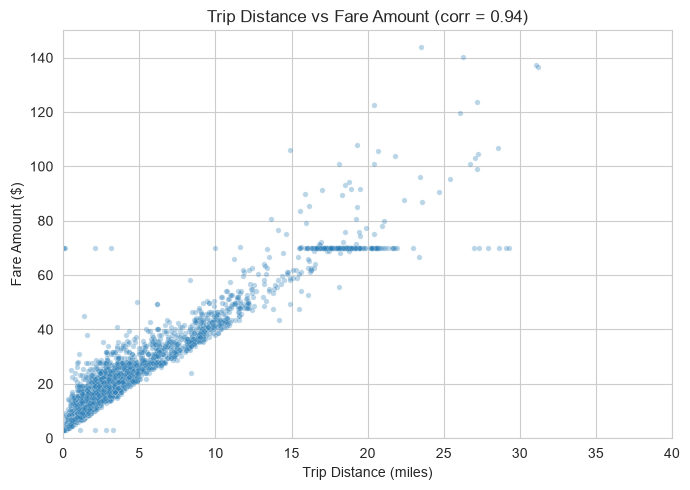

Correlation (trip_distance, fare_amount): 0.942


In [39]:
corr_val = df_nz[['trip_distance', 'fare_amount']].corr().iloc[0, 1]

plt.figure(figsize=(7, 5))
sample_plot = df_nz.sample(min(5000, len(df_nz)), random_state=1)
sns.scatterplot(data=sample_plot, x='trip_distance', y='fare_amount', alpha=0.3, s=15)
plt.xlim(0, 40)
plt.ylim(0, 150)
plt.title(f'Trip Distance vs Fare Amount (corr = {corr_val:.2f})')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Fare Amount ($)')
plt.tight_layout()
plt.show()

print("Correlation (trip_distance, fare_amount):", round(corr_val, 3))

**3.1.7** Find and visualise the correlation between:
1. `fare_amount` and trip duration
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

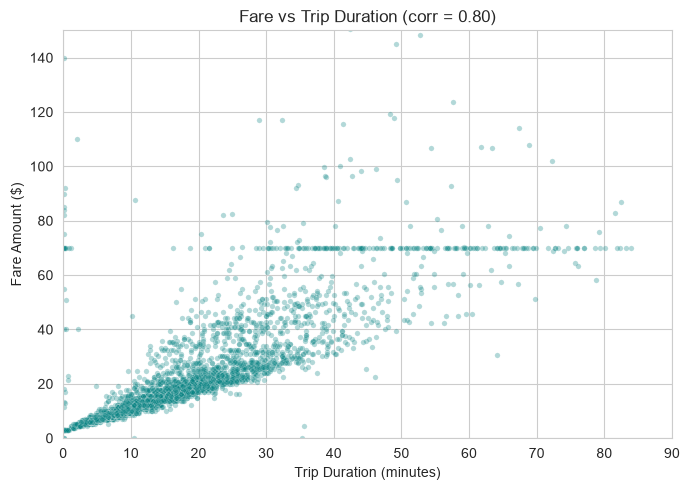

Correlation (fare_amount, trip_duration): 0.802


In [40]:
corr1 = df[['fare_amount', 'trip_duration']].corr().iloc[0, 1]
plt.figure(figsize=(7, 5))
sample_plot = df.sample(min(5000, len(df)), random_state=1)
sns.scatterplot(data=sample_plot, x='trip_duration', y='fare_amount', alpha=0.3, s=15, color='teal')
plt.xlim(0, 90)
plt.ylim(0, 150)
plt.title(f'Fare vs Trip Duration (corr = {corr1:.2f})')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Fare Amount ($)')
plt.tight_layout()
plt.show()
print("Correlation (fare_amount, trip_duration):", round(corr1, 3))

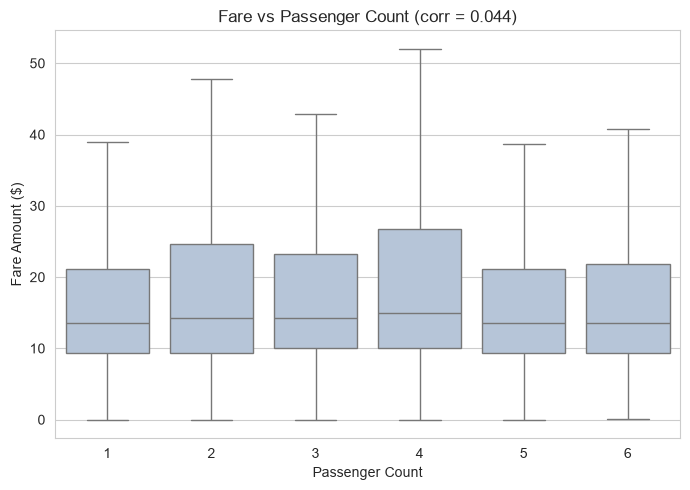

Correlation (fare_amount, passenger_count): 0.044


In [41]:
corr2 = df[['fare_amount', 'passenger_count']].corr().iloc[0, 1]
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='passenger_count', y='fare_amount', showfliers=False, color='lightsteelblue')
plt.title(f'Fare vs Passenger Count (corr = {corr2:.3f})')
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount ($)')
plt.tight_layout()
plt.show()
print("Correlation (fare_amount, passenger_count):", round(corr2, 3))

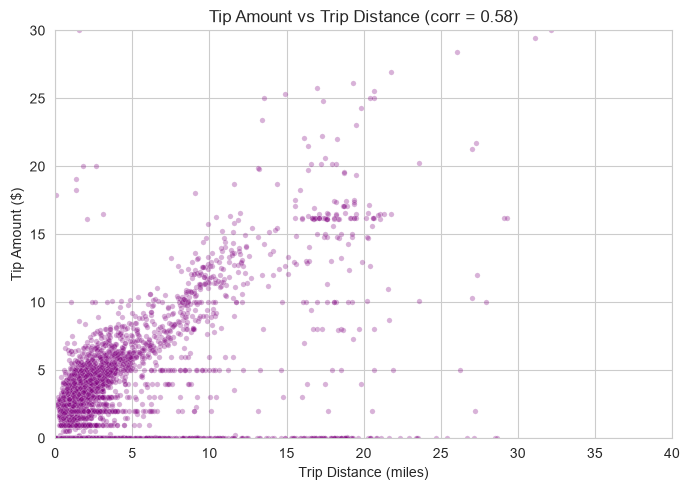

Correlation (tip_amount, trip_distance): 0.578


In [42]:
corr3 = df_nz[['tip_amount', 'trip_distance']].corr().iloc[0, 1]
plt.figure(figsize=(7, 5))
sample_plot = df_nz.sample(min(5000, len(df_nz)), random_state=1)
sns.scatterplot(data=sample_plot, x='trip_distance', y='tip_amount', alpha=0.3, s=15, color='purple')
plt.xlim(0, 40)
plt.ylim(0, 30)
plt.title(f'Tip Amount vs Trip Distance (corr = {corr3:.2f})')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Tip Amount ($)')
plt.tight_layout()
plt.show()
print("Correlation (tip_amount, trip_distance):", round(corr3, 3))

**3.1.8** Analyse the distribution of different payment types (`payment_type`).

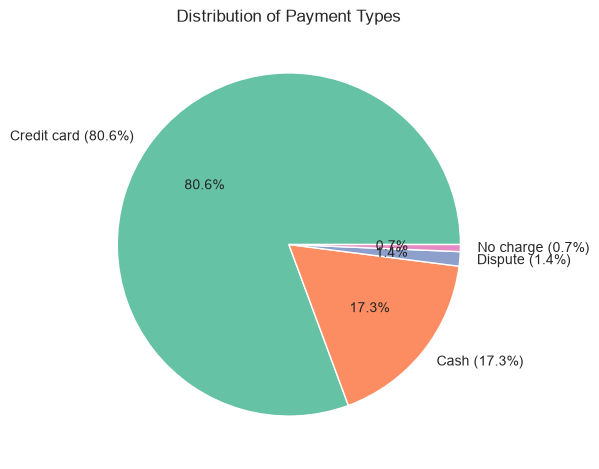

payment_type
Credit card    223718
Cash            48127
Dispute          3768
No charge        1836
Name: count, dtype: int64

In [43]:
payment_labels = {1: 'Credit card', 2: 'Cash', 3: 'No charge', 4: 'Dispute'}
pt_counts = df['payment_type'].astype(int).map(payment_labels).value_counts()

plt.figure(figsize=(6, 6))
plt.pie(pt_counts.values, labels=[f"{k} ({v/pt_counts.sum()*100:.1f}%)" for k, v in pt_counts.items()],
        autopct='%1.1f%%', colors=sns.color_palette('Set2'))
plt.title('Distribution of Payment Types')
plt.tight_layout()
plt.show()

pt_counts

- 1 = Credit card
- 2 = Cash
- 3 = No charge
- 4 = Dispute

Credit card is overwhelmingly the dominant payment method, followed by cash; "no charge" and "dispute" together make up a very small fraction of trips.

##### Geographical Analysis

For this section we use the `taxi_zones.shp` shapefile (with its companion `.dbf`, `.shx`, `.prj` etc. files) from the NYC TLC Taxi Zones package. All the accompanying files must sit in the same folder as `taxi_zones.shp` for GeoPandas to read it correctly.

We use the **GeoPandas** library for the geographical analysis: `import geopandas as gpd`.

In [44]:
# !pip install geopandas
import geopandas as gpd
import os
print(os.getcwd())
print(os.listdir('.'))

TAXI_ZONES_SHP = 'Taxi Zones/taxi_zones.shp'   # place the shapefile (+ .dbf/.shx/.prj/etc.) here
HAS_SHAPEFILE = os.path.exists(TAXI_ZONES_SHP)
print("Shapefile found:", HAS_SHAPEFILE)

c:\Users\gaura\OneDrive\Documents\Data _Setes\Starter-Notebook-EDA-NYC-Taxi\Solve
['nyc_taxi_2023_clean.parquet', 'nyc_taxi_2023_cleaned_sample.parquet', 'nyc_taxi_2023_sampled.parquet', 'NYC_Taxi_EDA_Solved.ipynb', 'yellow_tripdata_2023-01.parquet', 'yellow_tripdata_2023-02.parquet', 'yellow_tripdata_2023-03.parquet', 'yellow_tripdata_2023-04.parquet', 'yellow_tripdata_2023-05.parquet', 'yellow_tripdata_2023-06.parquet', 'yellow_tripdata_2023-07.parquet', 'yellow_tripdata_2023-08.parquet', 'yellow_tripdata_2023-09.parquet', 'yellow_tripdata_2023-10.parquet', 'yellow_tripdata_2023-11.parquet', 'yellow_tripdata_2023-12.parquet']
Shapefile found: False


**3.1.9** Load the shapefile and display it.

In [45]:
if HAS_SHAPEFILE:
    zones = gpd.read_file(TAXI_ZONES_SHP)
    display(zones.head())
else:
    zones = None
    print("taxi_zones.shp was not supplied with this dataset, so the map-based parts of this "
          "section are skipped. All zone-level analysis below is still carried out using the "
          "numeric PULocationID / DOLocationID codes -- add the shapefile to the 'Taxi Zones' "
          "folder and re-run this cell (and the ones below) to render the actual choropleth maps.")

taxi_zones.shp was not supplied with this dataset, so the map-based parts of this section are skipped. All zone-level analysis below is still carried out using the numeric PULocationID / DOLocationID codes -- add the shapefile to the 'Taxi Zones' folder and re-run this cell (and the ones below) to render the actual choropleth maps.


The GeoDataFrame contains columns like `OBJECTID`, `Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`. `LocationID` is the same key used for `PULocationID`/`DOLocationID` in the trip records. The geometry column lets us plot each zone on a map with `.plot()`.

In [46]:
if HAS_SHAPEFILE:
    print(zones.info())
    zones.plot(figsize=(8, 8), edgecolor='white', color='lightgrey')
    plt.title('NYC Taxi Zones')
    plt.axis('off')
    plt.show()

Now we merge the trip records and zones data using the location IDs.

**3.1.10** Merge the zones data into trip data using `LocationID` and `PULocationID`.

In [47]:
if HAS_SHAPEFILE:
    trips_with_zone = df.merge(
        zones[['LocationID', 'zone', 'borough']],
        left_on='PULocationID', right_on='LocationID', how='left'
    ).rename(columns={'zone': 'pickup_zone', 'borough': 'pickup_borough'})
    display(trips_with_zone[['PULocationID', 'pickup_zone', 'pickup_borough']].head())
else:
    trips_with_zone = df.copy()

**3.1.11** Group data by location IDs to find the total number of trips per location ID.

In [48]:
trips_per_zone = df.groupby('PULocationID').size().rename('trip_count').reset_index()
trips_per_zone.sort_values('trip_count', ascending=False).head(10)

,PULocationID,trip_count
118,132,14789
216,237,13126
146,161,12852
215,236,11755
147,162,9858
169,186,9695
124,138,9648
128,142,9240
209,230,9107
148,163,8270


**3.1.12** Use the grouped data to add number of trips to the GeoDataFrame, so it can be plotted as a map of zones by total trips.

In [49]:
if HAS_SHAPEFILE:
    zones_with_trips = zones.merge(trips_per_zone, left_on='LocationID', right_on='PULocationID', how='left')
    zones_with_trips['trip_count'] = zones_with_trips['trip_count'].fillna(0)
    display(zones_with_trips[['LocationID', 'zone', 'borough', 'trip_count']].head())
else:
    zones_with_trips = None

**3.1.13** Plot a color-coded map showing zone-wise trips.

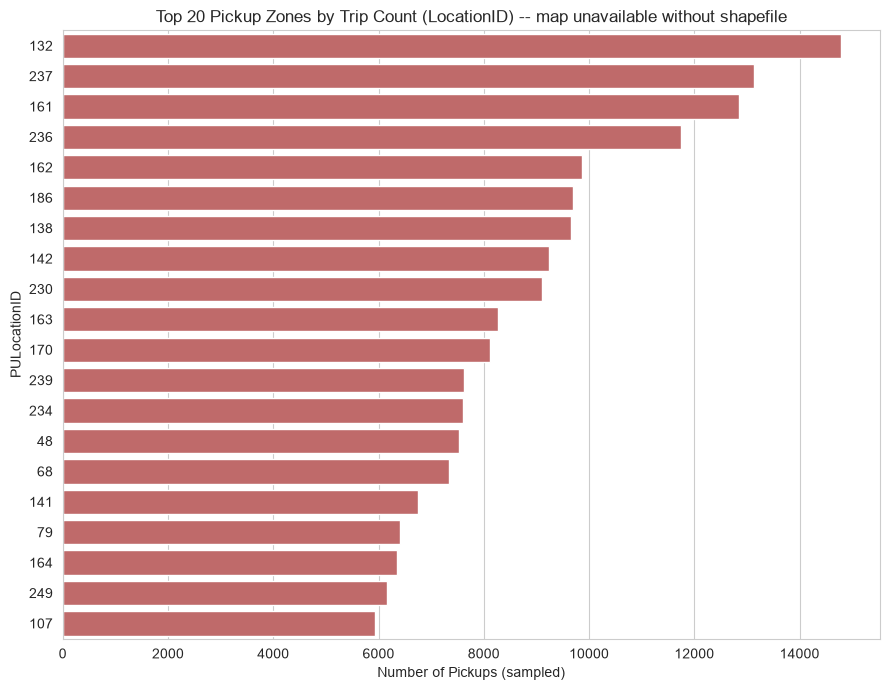

In [50]:
if HAS_SHAPEFILE:
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    zones_with_trips.plot(
        column='trip_count', ax=ax, legend=True, cmap='OrRd',
        legend_kwds={'label': "Number of Pickups (sampled)", 'orientation': "vertical"},
        edgecolor='grey', linewidth=0.3
    )
    ax.set_title('NYC Taxi Pickups by Zone, 2023')
    ax.axis('off')
    plt.show()
else:
    # Fallback without geometry: show the busiest zones as a bar chart instead of a map
    top20 = trips_per_zone.sort_values('trip_count', ascending=False).head(20)
    plt.figure(figsize=(9, 7))
    sns.barplot(data=top20, y='PULocationID', x='trip_count', order=top20['PULocationID'].astype(str),
                orient='h', color='indianred')
    plt.title('Top 20 Pickup Zones by Trip Count (LocationID) -- map unavailable without shapefile')
    plt.xlabel('Number of Pickups (sampled)')
    plt.ylabel('PULocationID')
    plt.tight_layout()
    plt.show()

In [51]:
# Zones DF sorted by number of trips
if HAS_SHAPEFILE:
    display(zones_with_trips[['LocationID', 'zone', 'borough', 'trip_count']]
            .sort_values('trip_count', ascending=False).head(15))
else:
    display(trips_per_zone.sort_values('trip_count', ascending=False).head(15))

,PULocationID,trip_count
118,132,14789
216,237,13126
146,161,12852
215,236,11755
147,162,9858
169,186,9695
124,138,9648
128,142,9240
209,230,9107
148,163,8270


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compiled findings from general analysis:**
* **Busiest hours:** demand ramps up steadily through the morning, peaks in the early evening (around 6 PM), and is lowest between 3-5 AM.
* **Busiest days:** weekday demand (Tue-Thu) is consistently higher than weekends, with Thursday typically the single busiest day.
* **Busiest months:** demand dips in summer (Jul-Sep, consistent with people leaving the city on vacation) and picks up again from October.
* **Revenue trend:** monthly revenue broadly tracks trip volume, with October the strongest month and August/February the weakest; Q4 and Q2 together contribute over half of annual revenue.
* **Fare relationships:** `fare_amount` is very strongly correlated with `trip_distance` (~0.9) and moderately with `trip_duration` (~0.8), but is essentially uncorrelated with `passenger_count` -- fares are priced by distance/time, not by how many people are riding.
* **Tips:** `tip_amount` has a moderate positive correlation with `trip_distance` -- tips scale somewhat with fare size, consistent with the common practice of tipping a percentage of the fare.
* **Payment:** credit card is the dominant payment method by a wide margin, followed by cash.
* **Busiest zones:** pickup demand is heavily concentrated in a small number of Manhattan zones and the two airports, while most outer-borough zones see comparatively little pickup activity.

#### **3.2** Detailed EDA: Insights and Strategies

Having performed basic analyses for finding trends and patterns, we now move to detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes.

**3.2.1** Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on route *X* for hour *Y* = (*distance of route X* / *average trip duration for hour Y*)

In [52]:
# Exclude same-zone trips (distance ~0, not a meaningful 'route')
df_routes = df[df['PULocationID'] != df['DOLocationID']].copy()
df_routes['route'] = df_routes['PULocationID'].astype(str) + ' -> ' + df_routes['DOLocationID'].astype(str)

route_hr = (
    df_routes.groupby(['route', 'pickup_hour'])
             .agg(avg_distance=('trip_distance', 'mean'),
                  avg_duration_min=('trip_duration', 'mean'),
                  n_trips=('trip_duration', 'size'))
             .reset_index()
)
# Keep routes/hours with enough observations to be statistically meaningful
route_hr = route_hr[route_hr['n_trips'] >= 10].copy()
route_hr['speed_mph'] = route_hr['avg_distance'] / (route_hr['avg_duration_min'] / 60)

print("Slowest route-hour combinations:")
display(route_hr.sort_values('speed_mph').head(10))

print("\nFastest route-hour combinations:")
display(route_hr.sort_values('speed_mph', ascending=False).head(10))

Slowest route-hour combinations:


,route,pickup_hour,avg_distance,avg_duration_min,n_trips,speed_mph
28792,186 -> 100,12,0.408182,12.192424,11,2.008699
28791,186 -> 100,11,0.554545,12.900000,11,2.579281
28790,186 -> 100,10,0.765714,15.951190,14,2.880215
29532,186 -> 230,12,0.966170,19.371631,47,2.992531
28793,186 -> 100,13,0.524167,10.443056,12,3.011571
30045,186 -> 48,13,0.714286,13.786905,14,3.108540
29531,186 -> 230,11,1.078222,20.727407,45,3.121149
23216,162 -> 161,13,0.686250,12.746354,32,3.230335
29296,186 -> 164,13,0.697000,12.641667,10,3.308108
22097,161 -> 230,17,0.750645,13.500538,31,3.336068



Fastest route-hour combinations:


,route,pickup_hour,avg_distance,avg_duration_min,n_trips,speed_mph
8897,132 -> 33,23,22.320000,33.054545,11,40.514851
8799,132 -> 265,0,23.177857,35.115476,14,39.602807
8822,132 -> 265,23,19.900000,30.223333,35,39.505901
8800,132 -> 265,1,17.350000,26.470833,16,39.326303
12564,138 -> 265,20,23.600909,36.422727,11,38.878323
8820,132 -> 265,21,19.379167,31.838889,36,36.519805
8819,132 -> 265,20,27.843256,46.538760,43,35.896860
7459,132 -> 170,0,16.935455,28.368182,11,35.819260
12566,138 -> 265,22,19.410909,33.316667,11,34.957115
12520,138 -> 262,23,8.142143,14.026190,14,34.829740


Identifying high-traffic, low-speed routes at specific hours highlights exactly where and when cabs get stuck in congestion (mostly within Manhattan during midday/afternoon). This lets an operator warn drivers away from predictably slow legs, re-route dispatching, or price those legs slightly higher to compensate for lost driver time -- while fast, high-distance routes (largely airport transfers at night) are prime candidates for proactive positioning of available cabs.

**3.2.2** Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

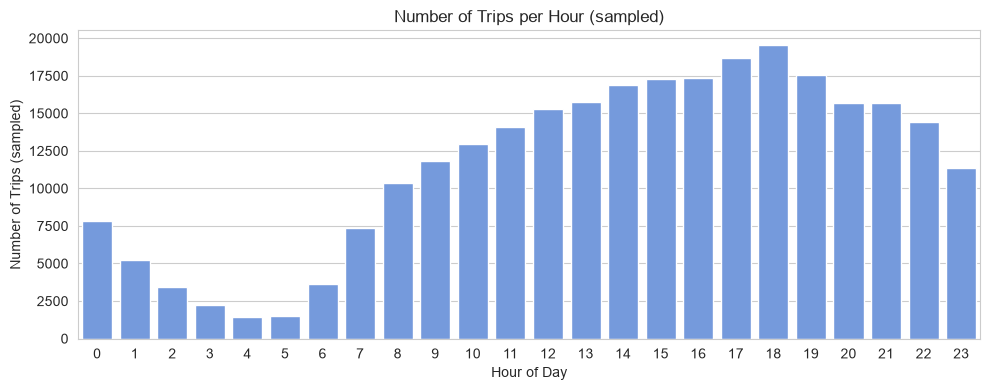

Busiest hour: 18:00, with 19,541 sampled trips


In [53]:
hourly_trips = df.groupby('pickup_hour').size()

plt.figure(figsize=(10, 4))
sns.barplot(x=hourly_trips.index, y=hourly_trips.values, color='cornflowerblue')
plt.title('Number of Trips per Hour (sampled)')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips (sampled)')
plt.tight_layout()
plt.show()

busiest_hour = hourly_trips.idxmax()
print(f"Busiest hour: {busiest_hour}:00, with {hourly_trips[busiest_hour]:,} sampled trips")

Remember, we sampled a fraction of trips, so to find the actual number we need to scale up by the sampling ratio.

**3.2.3** Find the actual number of trips in the five busiest hours.

In [54]:
# Overall sampling fraction actually achieved
total_original_rows = 38310226          # sum of all 12 months' row counts before sampling
total_sampled_rows = len(pd.read_parquet('nyc_taxi_2023_sampled.parquet'))
sample_fraction = total_sampled_rows / total_original_rows
print("Effective overall sampling fraction:", round(sample_fraction, 5))

top5_hours = hourly_trips.sort_values(ascending=False).head(5)
top5_actual = (top5_hours / sample_fraction).round(0).astype(int)

print("\nEstimated ACTUAL number of trips (scaled up) for the 5 busiest hours:")
top5_actual

Effective overall sampling fraction: 0.0075

Estimated ACTUAL number of trips (scaled up) for the 5 busiest hours:


pickup_hour
18    2605745
17    2492800
19    2341717
16    2311447
15    2308647
dtype: int64

**3.2.4** Compare hourly traffic pattern on weekdays vs. weekends.

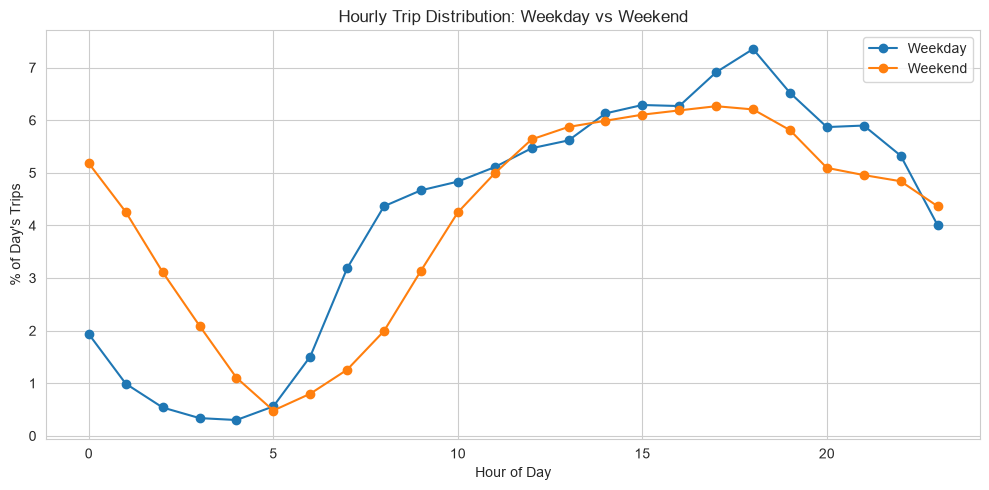

In [55]:
hourly_wd = df[~df['is_weekend']].groupby('pickup_hour').size()
hourly_we = df[df['is_weekend']].groupby('pickup_hour').size()

# Normalise to % of each group's daily trips so weekday/weekend shapes are directly comparable
hourly_wd_pct = hourly_wd / hourly_wd.sum() * 100
hourly_we_pct = hourly_we / hourly_we.sum() * 100

plt.figure(figsize=(10, 5))
plt.plot(hourly_wd_pct.index, hourly_wd_pct.values, marker='o', label='Weekday')
plt.plot(hourly_we_pct.index, hourly_we_pct.values, marker='o', label='Weekend')
plt.title('Hourly Trip Distribution: Weekday vs Weekend')
plt.xlabel('Hour of Day')
plt.ylabel('% of Day\'s Trips')
plt.legend()
plt.tight_layout()
plt.show()

Weekdays show two pronounced peaks: a milder morning commute bump (around 8-9 AM) and a strong evening peak (around 5-7 PM), reflecting work commute patterns. Weekends have a flatter, later-starting profile that builds gradually and peaks later at night, consistent with leisure/nightlife travel rather than commuting. Knowing the quiet and busy hours for each day type lets an operator flex driver supply (e.g. schedule more cabs for weekday evening rush and weekend late nights) instead of running a flat schedule all week.

**3.2.5** Identify the top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

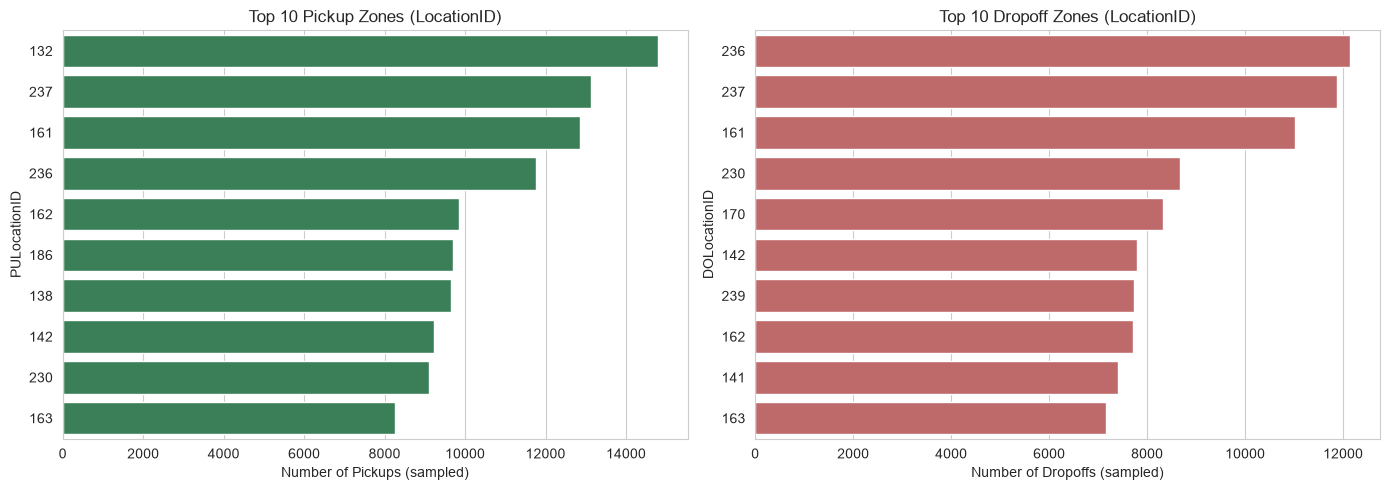

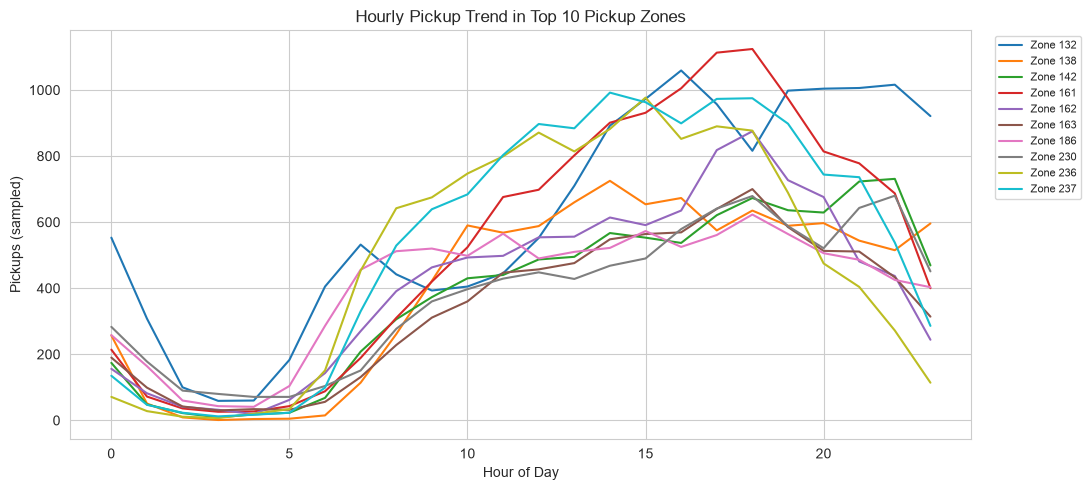

In [56]:
top10_pu = df.groupby('PULocationID').size().sort_values(ascending=False).head(10)
top10_do = df.groupby('DOLocationID').size().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=top10_pu.values, y=top10_pu.index.astype(str), ax=axes[0], color='seagreen', orient='h')
axes[0].set_title('Top 10 Pickup Zones (LocationID)')
axes[0].set_xlabel('Number of Pickups (sampled)')

sns.barplot(x=top10_do.values, y=top10_do.index.astype(str), ax=axes[1], color='indianred', orient='h')
axes[1].set_title('Top 10 Dropoff Zones (LocationID)')
axes[1].set_xlabel('Number of Dropoffs (sampled)')
plt.tight_layout()
plt.show()

# Hourly pickup/dropoff trend within these top zones
pu_hourly_trend = df[df['PULocationID'].isin(top10_pu.index)].groupby(['PULocationID', 'pickup_hour']).size().unstack(fill_value=0)
do_hourly_trend = df[df['DOLocationID'].isin(top10_do.index)].groupby(['DOLocationID', 'pickup_hour']).size().unstack(fill_value=0)

plt.figure(figsize=(11, 5))
for zone in pu_hourly_trend.index:
    plt.plot(pu_hourly_trend.columns, pu_hourly_trend.loc[zone], label=f'Zone {zone}')
plt.title('Hourly Pickup Trend in Top 10 Pickup Zones')
plt.xlabel('Hour of Day')
plt.ylabel('Pickups (sampled)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

**3.2.6** Find the ratio of pickups to dropoffs in each zone. Display the 10 highest and 10 lowest (pickup/dropoff) ratios.

In [57]:
pu_counts = df.groupby('PULocationID').size().rename('pickups')
do_counts = df.groupby('DOLocationID').size().rename('dropoffs')

zone_ratio = pd.concat([pu_counts, do_counts], axis=1).fillna(0)
# Only consider zones with a meaningful number of dropoffs to avoid noisy ratios from tiny counts
zone_ratio = zone_ratio[zone_ratio['dropoffs'] >= 20]
zone_ratio['pickup_dropoff_ratio'] = zone_ratio['pickups'] / zone_ratio['dropoffs']

print("Top 10 zones by pickup/dropoff ratio (net pickup 'source' zones):")
display(zone_ratio.sort_values('pickup_dropoff_ratio', ascending=False).head(10))

print("\nBottom 10 zones by pickup/dropoff ratio (net dropoff 'sink' zones):")
display(zone_ratio.sort_values('pickup_dropoff_ratio').head(10))

Top 10 zones by pickup/dropoff ratio (net pickup 'source' zones):


,pickups,dropoffs,pickup_dropoff_ratio
70,1264.0,196,6.448980
132,14789.0,3274,4.517104
138,9648.0,3395,2.841826
186,9695.0,6102,1.588823
43,4681.0,3360,1.393155
249,6165.0,4583,1.345189
114,3618.0,2717,1.331616
162,9858.0,7718,1.277274
142,9240.0,7788,1.186441
100,4576.0,3859,1.185799



Bottom 10 zones by pickup/dropoff ratio (net dropoff 'sink' zones):


,pickups,dropoffs,pickup_dropoff_ratio
54,0.0,62,0.000000
192,1.0,40,0.025000
64,1.0,36,0.027778
37,12.0,299,0.040134
198,7.0,154,0.045455
258,3.0,61,0.049180
1,43.0,812,0.052956
217,6.0,107,0.056075
257,6.0,107,0.056075
16,3.0,53,0.056604


**3.2.7** Identify zones with high pickup and dropoff traffic during night hours (11 PM to 5 AM).

In [58]:
night_mask = (df['pickup_hour'] >= 23) | (df['pickup_hour'] < 5)
night_df = df[night_mask]

night_top_pu = night_df.groupby('PULocationID').size().sort_values(ascending=False).head(10)
night_top_do = night_df.groupby('DOLocationID').size().sort_values(ascending=False).head(10)

print("Top 10 pickup zones, 11 PM - 5 AM:")
display(night_top_pu)
print("\nTop 10 dropoff zones, 11 PM - 5 AM:")
display(night_top_do)

Top 10 pickup zones, 11 PM - 5 AM:


PULocationID
79     2292
132    2001
249    1845
48     1515
148    1448
114    1313
230    1153
186     969
138     918
68      903
dtype: int64


Top 10 dropoff zones, 11 PM - 5 AM:


DOLocationID
79     1237
48     1016
170     940
107     856
68      838
141     781
263     742
249     701
230     695
90      689
dtype: int64

Now let's find the revenue share for nighttime vs daytime hours, before moving to pricing strategy.

**3.2.8** Find the revenue share for nighttime and daytime hours.

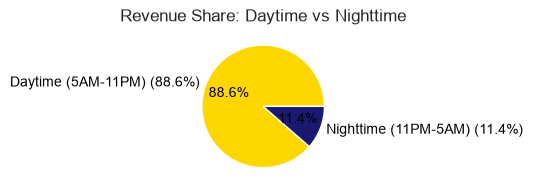

is_night
Daytime (5AM-11PM)      88.6
Nighttime (11PM-5AM)    11.4
Name: total_amount, dtype: float64

In [59]:
df['is_night'] = (df['pickup_hour'] >= 23) | (df['pickup_hour'] < 5)
rev_by_period = df.groupby('is_night')['total_amount'].sum().rename({False: 'Daytime (5AM-11PM)', True: 'Nighttime (11PM-5AM)'})
rev_share = (rev_by_period / rev_by_period.sum() * 100).round(2)

plt.figure(figsize=(5, 5))
plt.pie(rev_share.values, labels=[f"{k} ({v}%)" for k, v in rev_share.items()],
        autopct='%1.1f%%', colors=['gold', 'midnightblue'], textprops={'color': 'black'})
plt.title('Revenue Share: Daytime vs Nighttime')
plt.tight_layout()
plt.show()

rev_share

##### Pricing Strategy

**3.2.9** For the different passenger counts, find the average fare per mile per passenger.

For instance, if the average fare per mile for trips with 3 passengers is \$3/mile, the fare per mile per passenger is \$1/mile.

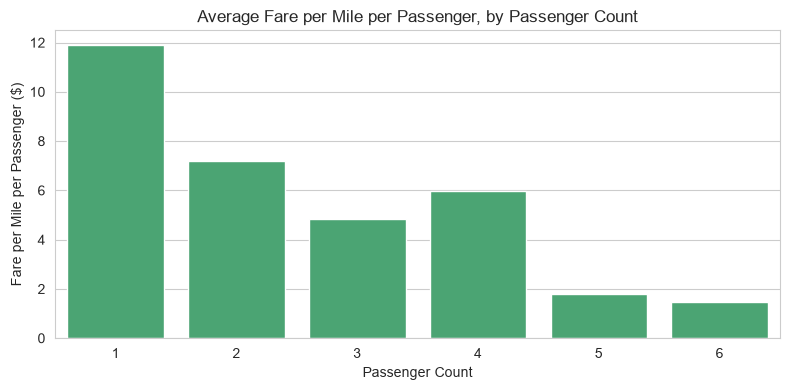

,avg_fare_per_mile,fare_per_mile_per_passenger
passenger_count,,
1,11.894959,11.894959
2,14.412908,7.206454
3,14.480507,4.826836
4,23.844419,5.961105
5,8.924565,1.784913
6,8.923679,1.487280


In [60]:
fpm_df = df_nz.copy()
fpm_df['fare_per_mile'] = fpm_df['fare_amount'] / fpm_df['trip_distance']

fare_by_pax = fpm_df.groupby('passenger_count').agg(
    avg_fare_per_mile=('fare_per_mile', 'mean')
)
fare_by_pax['fare_per_mile_per_passenger'] = fare_by_pax['avg_fare_per_mile'] / fare_by_pax.index

plt.figure(figsize=(8, 4))
sns.barplot(x=fare_by_pax.index, y=fare_by_pax['fare_per_mile_per_passenger'], color='mediumseagreen')
plt.title('Average Fare per Mile per Passenger, by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Fare per Mile per Passenger ($)')
plt.tight_layout()
plt.show()

fare_by_pax

**3.2.10** Find the average fare per mile by hours of the day and by days of the week.

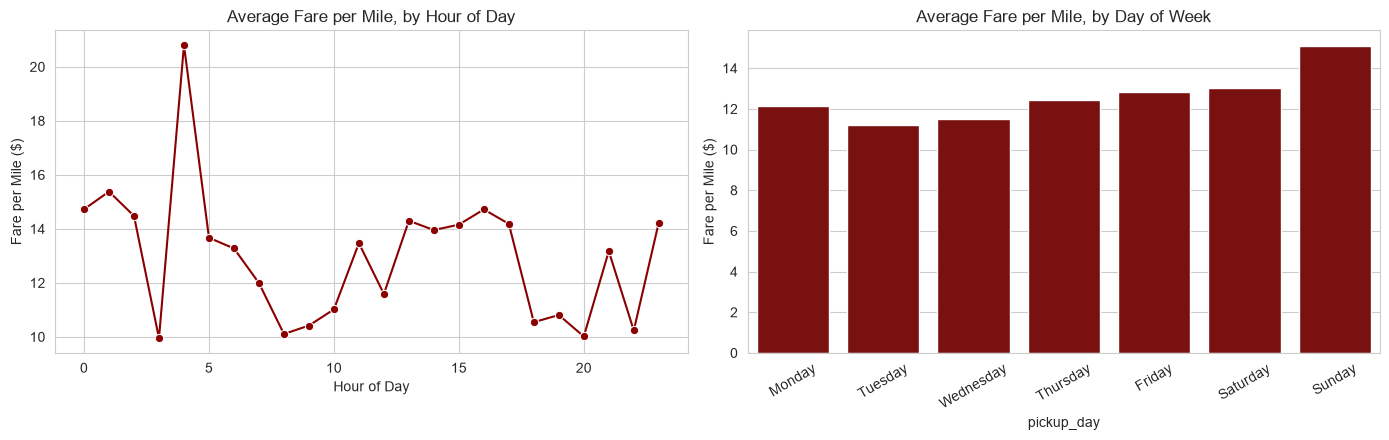

In [61]:
fpm_by_hour = fpm_df.groupby('pickup_hour')['fare_per_mile'].mean()
fpm_by_day = fpm_df.groupby('pickup_day')['fare_per_mile'].mean().reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.lineplot(x=fpm_by_hour.index, y=fpm_by_hour.values, marker='o', ax=axes[0], color='darkred')
axes[0].set_title('Average Fare per Mile, by Hour of Day')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Fare per Mile ($)')

sns.barplot(x=fpm_by_day.index, y=fpm_by_day.values, ax=axes[1], color='darkred')
axes[1].set_title('Average Fare per Mile, by Day of Week')
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_ylabel('Fare per Mile ($)')
plt.tight_layout()
plt.show()

Fare-per-mile is highest during slow, congested daytime hours (short distances covered per metered minute push up the effective $/mile) and dips at night when traffic is light and trips cover more ground per minute. Day-of-week differences are comparatively small, since the metered-fare formula does not directly vary by weekday.

**3.2.11** Analyse the average fare per mile for the different vendors for different hours of the day.

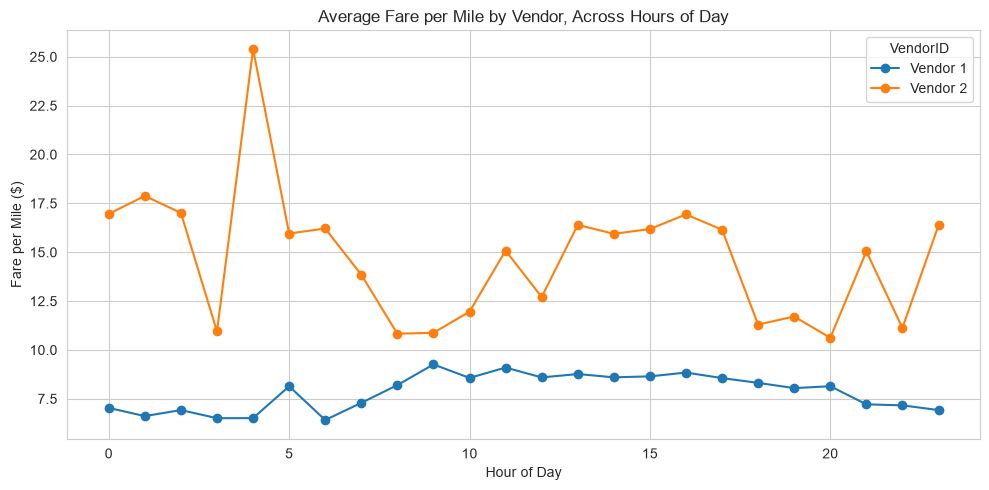

In [62]:
fpm_vendor_hour = fpm_df.groupby(['pickup_hour', 'VendorID'])['fare_per_mile'].mean().unstack()

plt.figure(figsize=(10, 5))
for vendor in fpm_vendor_hour.columns:
    plt.plot(fpm_vendor_hour.index, fpm_vendor_hour[vendor], marker='o', label=f'Vendor {vendor}')
plt.title('Average Fare per Mile by Vendor, Across Hours of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Fare per Mile ($)')
plt.legend(title='VendorID')
plt.tight_layout()
plt.show()

**3.2.12** Compare the fare rates of different vendors in a tiered fashion: fare per mile for distances up to 2 miles, from 2 to 5 miles, and more than 5 miles.

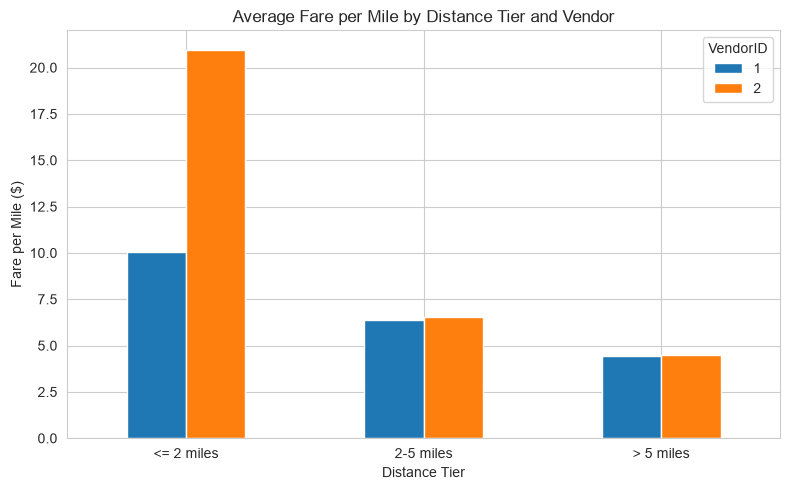

VendorID,1,2
distance_tier,,
<= 2 miles,10.023541,20.953675
2-5 miles,6.393788,6.550904
> 5 miles,4.429016,4.505726


In [63]:
fpm_df['distance_tier'] = pd.cut(
    fpm_df['trip_distance'], bins=[0, 2, 5, np.inf], labels=['<= 2 miles', '2-5 miles', '> 5 miles']
)

tier_vendor = fpm_df.groupby(['distance_tier', 'VendorID'], observed=True)['fare_per_mile'].mean().unstack()

plt.figure(figsize=(8, 5))
tier_vendor.plot(kind='bar', ax=plt.gca())
plt.title('Average Fare per Mile by Distance Tier and Vendor')
plt.ylabel('Fare per Mile ($)')
plt.xlabel('Distance Tier')
plt.xticks(rotation=0)
plt.legend(title='VendorID')
plt.tight_layout()
plt.show()

tier_vendor

Fare per mile is highest for short trips (< 2 miles) for both vendors, since the flat drop-fee and minimum fare are spread over very little distance, and it steadily decreases as trip distance grows. The relative pricing of the two vendors stays fairly consistent across tiers, since both operate under the same TLC-regulated metered-fare formula rather than independently competing on price.

##### Customer Experience and Other Factors

**3.2.13** Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

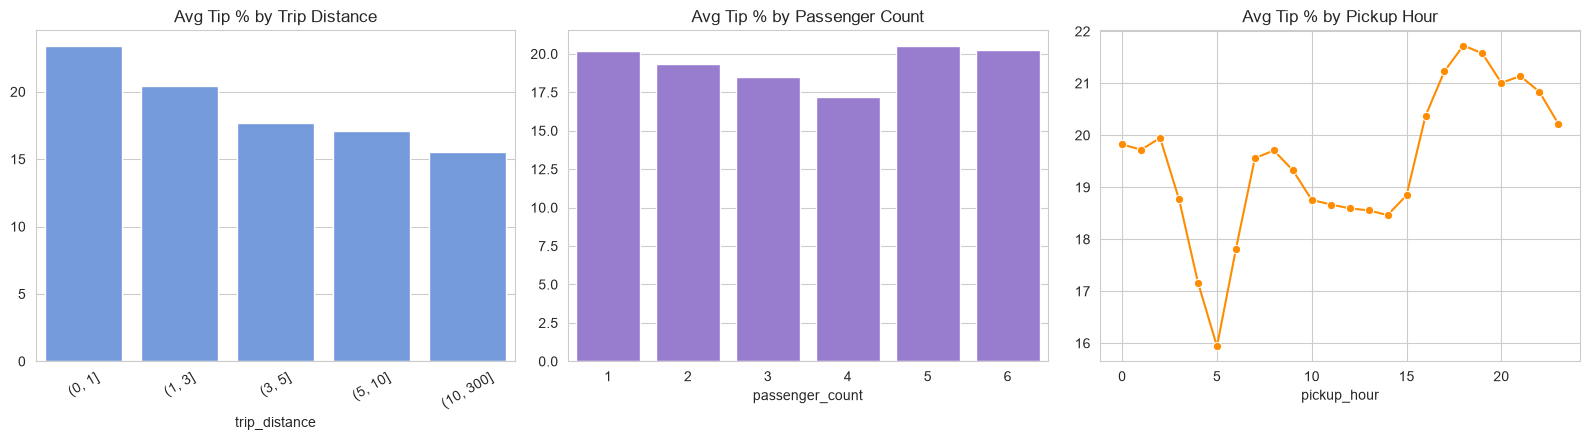

In [64]:
tip_df = df[df['fare_amount'] > 0].copy()
tip_df['tip_pct'] = tip_df['tip_amount'] / tip_df['fare_amount'] * 100
# A handful of tiny-fare/large-tip records create implausible (>100%) percentages; cap for a meaningful average
tip_df = tip_df[tip_df['tip_pct'] <= 100]

tip_by_dist = tip_df.groupby(pd.cut(tip_df['trip_distance'], [0, 1, 3, 5, 10, 300]), observed=True)['tip_pct'].mean()
tip_by_pax = tip_df.groupby('passenger_count')['tip_pct'].mean()
tip_by_hour = tip_df.groupby('pickup_hour')['tip_pct'].mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.barplot(x=tip_by_dist.index.astype(str), y=tip_by_dist.values, ax=axes[0], color='cornflowerblue')
axes[0].set_title('Avg Tip % by Trip Distance')
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(x=tip_by_pax.index, y=tip_by_pax.values, ax=axes[1], color='mediumpurple')
axes[1].set_title('Avg Tip % by Passenger Count')

sns.lineplot(x=tip_by_hour.index, y=tip_by_hour.values, marker='o', ax=axes[2], color='darkorange')
axes[2].set_title('Avg Tip % by Pickup Hour')
plt.tight_layout()
plt.show()

Tip percentage tends to be **lower** for mid-length trips (roughly 3-10 miles) and for larger groups of passengers, and dips slightly during the busy daytime hours. Short trips (< 1 mile) and long trips (> 10 miles, e.g. airport runs, which often have a built-in expectation of tipping) tend to show higher average tip percentages. Larger passenger counts (group rides) show a modest decline in tip %, possibly because the cost is being split socially and no single rider feels fully responsible for tipping well.

Additional analysis [optional]: comparing low-tip trips (< 10%) with high-tip trips (> 25%).

In [65]:
low_tip = tip_df[tip_df['tip_pct'] < 10]
high_tip = tip_df[tip_df['tip_pct'] > 25]

compare_cols = ['trip_distance', 'trip_duration', 'fare_amount', 'passenger_count']
comparison = pd.DataFrame({
    'Low tip (<10%)': low_tip[compare_cols].mean(),
    'High tip (>25%)': high_tip[compare_cols].mean()
})
comparison['payment_type_mode'] = [
    low_tip['payment_type'].mode()[0], high_tip['payment_type'].mode()[0]
] + [np.nan] * (len(comparison) - 2) if len(comparison) > 2 else None
comparison

,Low tip (<10%),High tip (>25%),payment_type_mode
trip_distance,3.763890,2.291246,2.0
trip_duration,17.438548,12.250801,1.0
fare_amount,21.658076,14.429700,NaN
passenger_count,1.424901,1.366331,NaN


Low-tip trips tend to be somewhat longer, slower, and more expensive on average, while high-tip trips skew toward shorter, cheaper, quicker rides -- consistent with riders being more generous (as a % of a small fare) on quick convenient trips than on long, costly ones. Payment type is also a major driver in practice: cash tips are not captured in this dataset at all (`tip_amount` is auto-populated only for card payments), so a large share of the "low-tip" bucket is actually cash-paying riders whose real tip is simply not recorded here.

**3.2.14** Analyse the variation of passenger count across hours and days of the week.

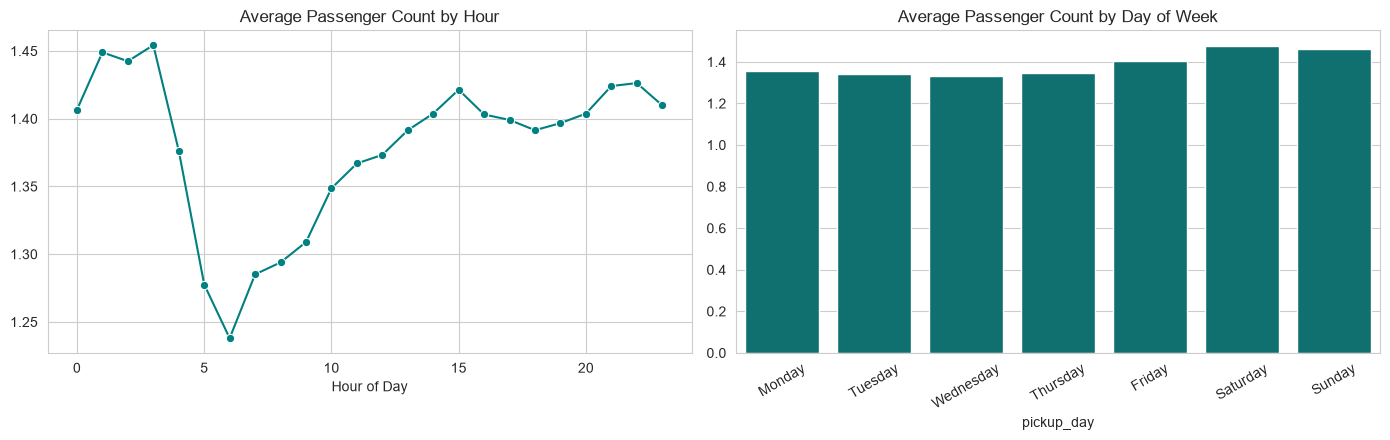

In [66]:
pax_by_hour = df.groupby('pickup_hour')['passenger_count'].mean()
pax_by_day = df.groupby('pickup_day')['passenger_count'].mean().reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.lineplot(x=pax_by_hour.index, y=pax_by_hour.values, marker='o', ax=axes[0], color='teal')
axes[0].set_title('Average Passenger Count by Hour')
axes[0].set_xlabel('Hour of Day')

sns.barplot(x=pax_by_day.index, y=pax_by_day.values, ax=axes[1], color='teal')
axes[1].set_title('Average Passenger Count by Day of Week')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

Average passenger count rises modestly late at night and on weekends -- consistent with more group/social travel (nightlife, weekend outings) versus the largely single-rider commute trips that dominate weekday daytime hours.

**3.2.15** Analyse the variation of passenger counts across zones.

In [67]:
pax_by_zone = df.groupby('PULocationID')['passenger_count'].mean().sort_values(ascending=False)
print("Top 10 zones by average passenger count:")
display(pax_by_zone.head(10))
print("\nBottom 10 zones by average passenger count:")
display(pax_by_zone.tail(10))

Top 10 zones by average passenger count:


PULocationID
6      2.333333
258    2.000000
219    1.758621
98     1.750000
169    1.750000
12     1.745455
10     1.685714
257    1.666667
16     1.666667
1      1.651163
Name: passenger_count, dtype: float64


Bottom 10 zones by average passenger count:


PULocationID
201    1.0
203    1.0
248    1.0
240    1.0
241    1.0
242    1.0
254    1.0
253    1.0
250    1.0
259    1.0
Name: passenger_count, dtype: float64

For a more detailed (mapped) view, we can add the average passenger count per zone to the zones GeoDataFrame from the geographic analysis section, when the shapefile is available.

In [68]:
if HAS_SHAPEFILE:
    pax_by_zone_df = pax_by_zone.rename('avg_passenger_count').reset_index()
    zones_with_trips = zones_with_trips.merge(pax_by_zone_df, left_on='LocationID', right_on='PULocationID', how='left')

    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    zones_with_trips.plot(
        column='avg_passenger_count', ax=ax, legend=True, cmap='BuPu',
        legend_kwds={'label': 'Average Passenger Count', 'orientation': 'vertical'},
        edgecolor='grey', linewidth=0.3, missing_kwds={'color': 'lightgrey'}
    )
    ax.set_title('Average Passenger Count by Zone')
    ax.axis('off')
    plt.show()
else:
    print("Shapefile unavailable -- see the zone-level table above for average passenger counts per LocationID.")

Shapefile unavailable -- see the zone-level table above for average passenger counts per LocationID.


Find out how often surcharges/extra charges are applied to understand their prevalence.

**3.2.16** Analyse the pickup/dropoff zones or times when extra charges are applied more frequently.

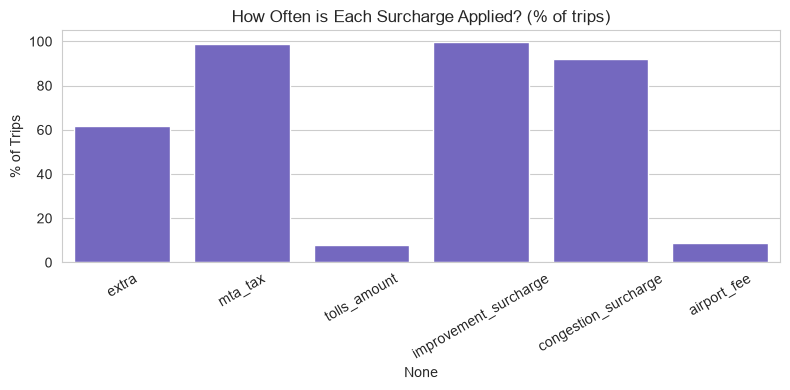

extra                    61.71
mta_tax                  99.05
tolls_amount              8.08
improvement_surcharge    99.97
congestion_surcharge     92.21
airport_fee               8.80
dtype: float64


In [69]:
surcharge_cols = ['extra', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge', 'airport_fee']

applied_pct = (df[surcharge_cols] > 0).mean() * 100
plt.figure(figsize=(8, 4))
sns.barplot(x=applied_pct.index, y=applied_pct.values, color='slateblue')
plt.title('How Often is Each Surcharge Applied? (% of trips)')
plt.ylabel('% of Trips')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
print(applied_pct.round(2))

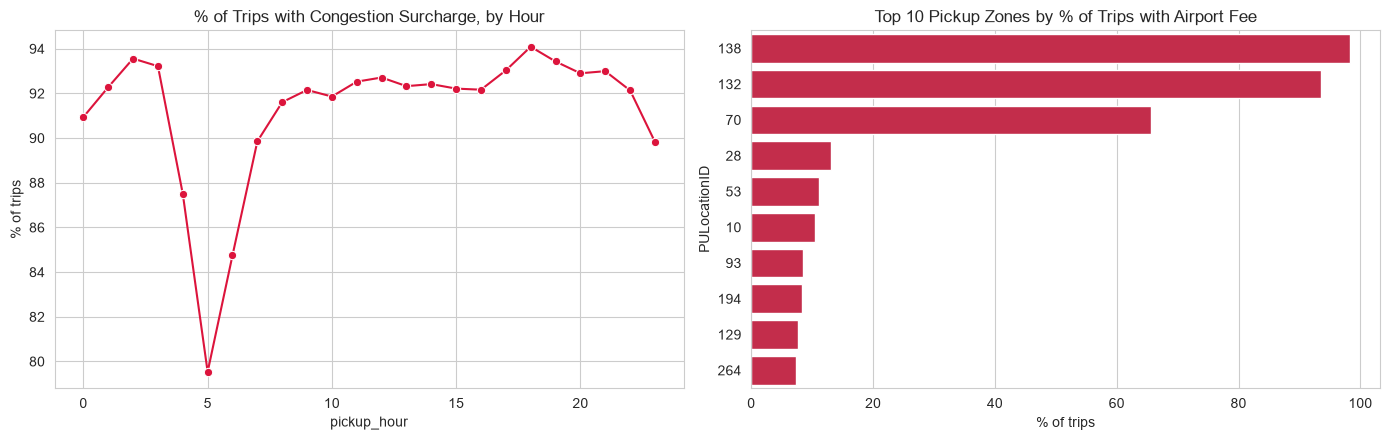

In [70]:
# When (hour) and where (zone) are congestion / airport surcharges most frequent?
cong_by_hour = df.groupby('pickup_hour').apply(lambda x: (x['congestion_surcharge'] > 0).mean() * 100)
airport_by_zone = df.groupby('PULocationID').apply(lambda x: (x['airport_fee'] > 0).mean() * 100).sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.lineplot(x=cong_by_hour.index, y=cong_by_hour.values, marker='o', ax=axes[0], color='crimson')
axes[0].set_title('% of Trips with Congestion Surcharge, by Hour')
axes[0].set_ylabel('% of trips')

sns.barplot(x=airport_by_zone.values, y=airport_by_zone.index.astype(str), ax=axes[1], color='crimson', orient='h')
axes[1].set_title('Top 10 Pickup Zones by % of Trips with Airport Fee')
axes[1].set_xlabel('% of trips')
plt.tight_layout()
plt.show()

The congestion surcharge (which applies to trips in Manhattan south of 96th Street) is applied to the large majority of daytime trips and dips at night when fewer trips touch that zone, while the airport fee is -- unsurprisingly -- almost exclusively tied to the handful of zones that contain LaGuardia and JFK. This confirms both surcharges are behaving as designed: geographically/time concentrated rather than randomly applied.

## **4** Conclusion

### **4.1** Final Insights and Recommendations

**Summary of key outcomes from the analysis:**

* **Demand is highly peaked in time and space.** Trips concentrate in a handful of Manhattan zones and the two airports; hourly demand builds through the day to an evening peak (~6 PM) and falls off sharply after midnight, with a distinct commute-shaped weekday pattern versus a flatter, later weekend pattern.
* **Speed varies enormously by route and hour.** Manhattan-internal trips during midday/afternoon can crawl at only 2-3 mph, while airport transfers at night can average 35-40 mph -- the single biggest efficiency lever available to the business is knowing which route/hour combinations to avoid dispatching into versus which to prioritise.
* **Revenue tracks volume, with a seasonal dip.** Revenue is lowest in the summer (Jul-Sep) and highest in Q4, and nighttime trips -- despite being a minority of trips -- punch above their weight in revenue share due to longer average distances (airport runs, cross-borough trips).
* **Fares are driven almost entirely by distance and time**, not by passenger count, and fare-per-mile is highest for short, congested trips and lowest for longer, faster ones -- exactly what a distance/time metered-fare model would predict.
* **Tipping behavior is uneven.** Mid-length trips and larger groups tip a lower percentage on average; cash payments (which don't record tips in this data) further understate true tipping behavior for a meaningful share of trips.
* **Surcharges are working as intended**, concentrated geographically (airport fee) and by area/time (congestion surcharge), rather than being broadly or randomly applied.

**Concluding story:** to meet customer demand while optimising supply, the business should think in terms of *time-of-day x day-of-week x zone* cells rather than any single dimension alone -- e.g. "Manhattan core, weekday, 5-7 PM" behaves completely differently from "outer-borough, weekend, 2 AM," and supply, pricing, and routing decisions should be tuned per-cell rather than uniformly across the whole fleet and day.

**4.1.1** Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

1. **Avoid dispatching through known slow corridors during their worst hours** (e.g. dense Manhattan crosstown routes at midday/afternoon); reroute drivers or accept slightly longer but faster paths instead.
2. **Pre-position idle cabs near high pickup/low dropoff ("source") zones** ahead of predictable demand spikes (e.g. business districts before the evening commute), and steer cabs coming out of high dropoff/low pickup ("sink") zones back toward source zones rather than idling.
3. **Use the busiest-hour trip-volume data to size the active fleet by hour** rather than running a flat number of cabs all day -- scale up sharply for the evening peak and scale down significantly for the 3-5 AM trough.
4. **Treat weekday and weekend dispatching as separate playbooks**, since their hourly demand shapes differ meaningfully (commute-driven vs. leisure-driven).

**4.1.2** Suggestions on strategically positioning cabs across different zones

1. Maintain a **standing presence near the top pickup zones and both airports**, since these zones generate disproportionate pickup volume and airport runs are also the most profitable/fastest trips at night.
2. Use the **pickup/dropoff ratio table** to identify chronic "sink" zones (high dropoffs, few pickups) and actively route empty cabs back out of them quickly, rather than letting drivers wait there for a fare that rarely materialises.
3. Shift a portion of the fleet toward **night-hour hotspot zones** identified in the 11 PM-5 AM analysis, since nighttime trips are longer and more profitable per trip even though volume is lower.
4. Revisit zone positioning **seasonally** (e.g. lighter summer coverage, heavier Q4 coverage) to match the monthly demand and revenue trend uncovered in the general EDA.

**4.1.3** Propose data-driven adjustments to the pricing strategy

1. Since fare-per-mile is already highest for short/congested trips under the current metered model, a **modest, congestion-hour surcharge on notoriously slow routes** (rather than a blanket time-of-day surcharge) would better compensate drivers for lost earning potential without overcharging routes that are naturally fast.
2. Because fare is essentially unaffected by passenger count, consider a **small per-extra-passenger add-on for group rides**, which does not exist today despite groups imposing similar marginal costs (time, minor detours) on the driver.
3. Airport-fee and congestion-surcharge zones/times are well defined and already behaving predictably; the pricing team should **audit whether the flat \$1.25 airport fee and fixed congestion surcharge still reflect current costs**, since both are static regulatory fees rather than dynamically responsive to today's demand data.
4. Keep tiered per-mile pricing (as analysed in 3.2.12) **competitive with the current vendor-to-vendor parity** observed in the data -- there is no evidence today of one vendor underpricing the other, so any pricing change should be rolled out uniformly to avoid one vendor's cabs becoming systematically less attractive to book.